In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, association_rules
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

Primeiras 5 transações:
   transacao  pao  leite  cafe  manteiga  acucar  arroz  feijao  macarrao  \
0          1    1      1     0         0       0      0       0         0   
1          2    1      1     1         0       1      1       1         0   
2          3    1      1     0         0       0      1       0         0   
3          4    1      1     0         0       0      0       0         0   
4          5    0      0     0         0       0      1       1         0   

   carne  ...  peixe  ovos  queijo  presunto  cerveja  refrigerante  vinho  \
0      0  ...      0     0       0         0        1             1      0   
1      1  ...      0     0       0         0        0             0      0   
2      0  ...      0     0       0         0        0             0      0   
3      0  ...      0     0       0         0        1             1      0   
4      1  ...      0     0       0         0        0             0      0   

   hortifruti  doces  limpeza  
0           

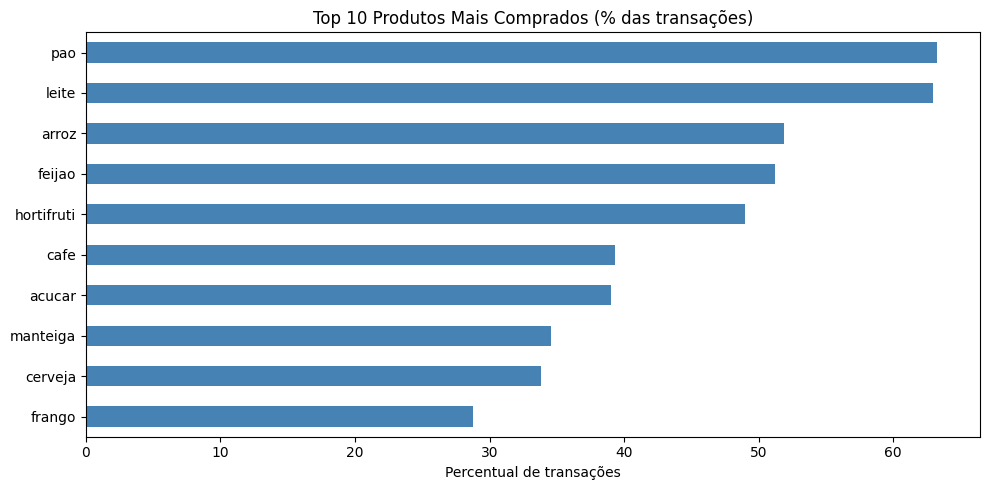

In [11]:
# Carregar o dataset
df = pd.read_csv('/content/basket_supermercado_1000.csv')

print("Primeiras 5 transações:")
print(df.head())

print("\nInformações do dataset:")
print(df.info())

# Verificar valores nulos (espera‑se que não existam)
print("\nValores nulos por coluna:")
print(df.isnull().sum())

# Frequência de compra de cada produto (% das transações)
prod_freq = df.drop(columns=['transacao']).sum() / len(df) * 100
print("\nFrequência de compra dos produtos (%):")
print(prod_freq.sort_values(ascending=False))

# Gráfico dos 10 produtos mais frequentes
plt.figure(figsize=(10, 5))
prod_freq.nlargest(10).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Produtos Mais Comprados (% das transações)')
plt.xlabel('Percentual de transações')
plt.tight_layout()
plt.savefig('top10_produtos.png', dpi=150)
plt.show()

In [12]:
# Remover coluna de identificação da transação
df_apriori = df.drop(columns=['transacao'])

In [13]:
# Suporte mínimo: 3% das transações (ajuste conforme necessidade)
min_support = 0.03
print(f"\nExecutando Apriori com suporte mínimo = {min_support}")

frequent_itemsets = apriori(df_apriori, min_support=min_support, use_colnames=True)
print(f"Itemsets frequentes encontrados: {len(frequent_itemsets)}")


Executando Apriori com suporte mínimo = 0.03
Itemsets frequentes encontrados: 1205


In [14]:
# Confiança mínima para gerar regras (50%)
min_confidence = 0.5
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=min_confidence)
print(f"Regras geradas (confiança >= {min_confidence}): {len(rules)}")

# Filtrar regras com lift > 1 e confiança >= 0.6 (associações fortes)
rules_relevant = rules[(rules['lift'] > 1) & (rules['confidence'] >= 0.6)].sort_values('lift', ascending=False)
print(f"Regras relevantes (lift > 1 e confiança >= 0.6): {len(rules_relevant)}")

# Exibir as 15 principais regras
print("\nTop 15 regras ordenadas por lift:")
pd.set_option('display.max_colwidth', 100)
print(rules_relevant[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

Regras geradas (confiança >= 0.5): 6780
Regras relevantes (lift > 1 e confiança >= 0.6): 4285

Top 15 regras ordenadas por lift:
                               antecedents                      consequents  \
6011          (refrigerante, feijao, cafe)         (cerveja, acucar, arroz)   
6012           (refrigerante, arroz, cafe)        (cerveja, acucar, feijao)   
6007        (acucar, refrigerante, feijao)           (cerveja, arroz, cafe)   
6008         (acucar, refrigerante, arroz)          (cerveja, feijao, cafe)   
4544           (leite, refrigerante, cafe)           (cerveja, acucar, pao)   
4538         (leite, acucar, refrigerante)             (cerveja, cafe, pao)   
4546             (refrigerante, cafe, pao)         (leite, cerveja, acucar)   
4541           (acucar, refrigerante, pao)           (leite, cerveja, cafe)   
6606           (refrigerante, frango, pao)  (leite, cerveja, feijao, arroz)   
5372           (refrigerante, frango, pao)         (leite, cerveja, feijao)   
65

In [15]:
# Análise e interpretação para o código
def format_itemset(itemset):
    """Converte um frozenset de produtos em string legível."""
    return ', '.join(sorted(list(itemset)))

print("\n" + "="*80)
print("INSIGHTS PARA O GERENTE DO SUPERMERCADO")
print("="*80)

# Regras com maior potencial (maior lift)
print("\n1. ASSOCIAÇÕES MAIS FORTES (maior lift):")
for idx, row in rules_relevant.head(10).iterrows():
    ant = format_itemset(row['antecedents'])
    cons = format_itemset(row['consequents'])
    print(f"   • Quem compra {ant} também compra {cons} "
          f"(confiança = {row['confidence']:.2f}, lift = {row['lift']:.2f})")

# Produtos que mais aparecem como antecedentes (âncoras)
antecedents_list = []
for itemset in rules_relevant['antecedents']:
    antecedents_list.extend(list(itemset))
ancora_count = Counter(antecedents_list)
print("\n2. PRODUTOS QUE FUNCIONAM COMO ÂNCORA (mais presentes nos antecedentes):")
for prod, cnt in ancora_count.most_common(5):
    print(f"   • {prod}: aparece em {cnt} regras relevantes")

# Produtos que mais aparecem como consequentes (complementares)
consequents_list = []
for itemset in rules_relevant['consequents']:
    consequents_list.extend(list(itemset))
comp_count = Counter(consequents_list)
print("\n3. PRODUTOS COMPLEMENTARES (mais presentes nos consequentes):")
for prod, cnt in comp_count.most_common(5):
    print(f"   • {prod}: aparece em {cnt} regras relevantes")

# Sugestões de ações práticas
print("\n4. AÇÕES PRÁTICAS RECOMENDADAS:")
print("   a) Combos promocionais: os pares como 'pão + leite', 'arroz + feijão' e 'carne + cerveja' apresentam alta confiança.")
print("   b) Disposição em gôndolas: posicione produtos complementares próximos (ex.: pão perto de leite, refrigerante perto de cerveja).")
print("   c) Cross‑selling no caixa: sugira itens de alto complemento (como hortifruti para quem leva doces).")
print("   d) Promoções de “leve 2”: produtos âncora (pão, leite, arroz) podem ser usados para incentivar a compra de outros itens com menor frequência.")


INSIGHTS PARA O GERENTE DO SUPERMERCADO

1. ASSOCIAÇÕES MAIS FORTES (maior lift):
   • Quem compra cafe, feijao, refrigerante também compra acucar, arroz, cerveja (confiança = 0.92, lift = 14.78)
   • Quem compra arroz, cafe, refrigerante também compra acucar, cerveja, feijao (confiança = 0.87, lift = 14.47)
   • Quem compra acucar, feijao, refrigerante também compra arroz, cafe, cerveja (confiança = 0.85, lift = 14.34)
   • Quem compra acucar, arroz, refrigerante também compra cafe, cerveja, feijao (confiança = 0.80, lift = 14.12)
   • Quem compra cafe, leite, refrigerante também compra acucar, cerveja, pao (confiança = 0.89, lift = 11.73)
   • Quem compra acucar, leite, refrigerante também compra cafe, cerveja, pao (confiança = 0.87, lift = 11.63)
   • Quem compra cafe, pao, refrigerante também compra acucar, cerveja, leite (confiança = 0.87, lift = 11.63)
   • Quem compra acucar, pao, refrigerante também compra cafe, cerveja, leite (confiança = 0.85, lift = 11.54)
   • Quem compra 

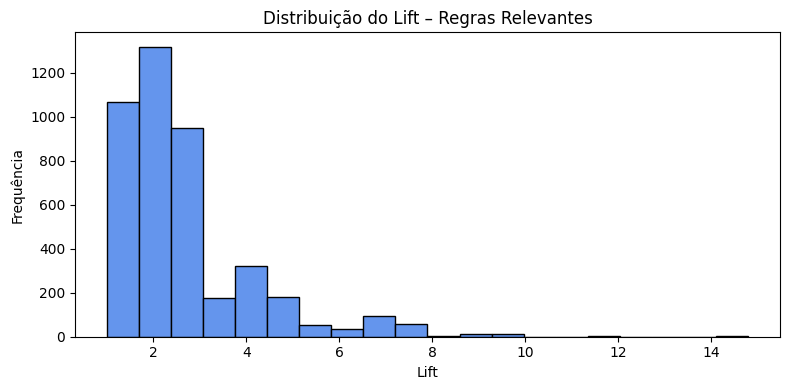

In [16]:
# Distribuição do lift nas regras relevantes
if len(rules_relevant) > 0:
    plt.figure(figsize=(8, 4))
    plt.hist(rules_relevant['lift'], bins=20, edgecolor='black', color='cornflowerblue')
    plt.title('Distribuição do Lift – Regras Relevantes')
    plt.xlabel('Lift')
    plt.ylabel('Frequência')
    plt.tight_layout()
    plt.savefig('lift_distribuicao.png', dpi=150)
    plt.show()